**Imports all the necessary Python libraries for data handling, machine learning, and visualization, such as Pandas, NumPy, Matplotlib, and Scikit-learn**

In [69]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

**Load the NSL-KDD training and testing datasets into the program and assigns appropriate column names to represent network traffic features.**

In [70]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_data = pd.read_csv("/content/IDS/KDDTrain+.txt", names=columns)
test_data = pd.read_csv("/content/IDS/KDDTest+.txt", names=columns)

**Convert the attack labels into a binary format where normal traffic is labeled as 0 and intrusion traffic is labeled as 1, enabling supervised machine learning.**

In [71]:
train_data['label'] = train_data['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

**Visualize the distribution of normal and intrusion traffic to understand dataset imbalance and analyze the proportion of malicious network connections.**

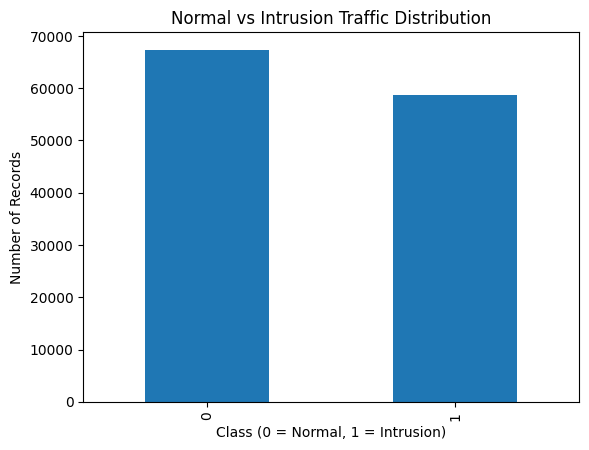

In [72]:
train_data['label'].value_counts().plot(kind='bar')
plt.title("Normal vs Intrusion Traffic Distribution")
plt.xlabel("Class (0 = Normal, 1 = Intrusion)")
plt.ylabel("Number of Records")
plt.show()

**Displays the distribution of different network protocols (TCP, UDP, ICMP) used in the dataset to understand network behavior patterns.**

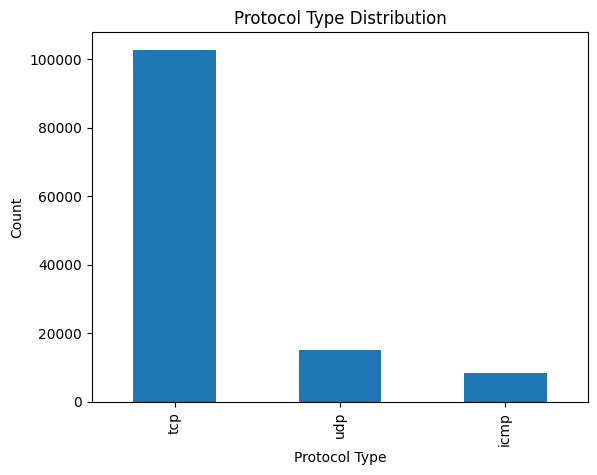

In [73]:
train_data['protocol_type'].value_counts().plot(kind='bar')
plt.title("Protocol Type Distribution")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

**Separate the dataset into input features and output labels, preparing the data for model training and testing.**

In [74]:
X_train = train_data.drop(['label', 'difficulty'], axis=1)
y_train = train_data['label']
X_test = test_data.copy()

**Convert categorical network attributes into numerical form using one-hot encoding and aligns training and testing features to ensure consistency.**

In [75]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(
    X_test, join='left', axis=1, fill_value=0
)

**Applly feature scaling to normalize the data, improving the performance and stability of the machine learning model.**

In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Train a Random Forest classifier using the preprocessed training data to learn patterns associated with network intrusions.**

In [77]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

**Evaluate the trained model using a confusion matrix to measure its ability to correctly classify normal and intrusion traffic.**

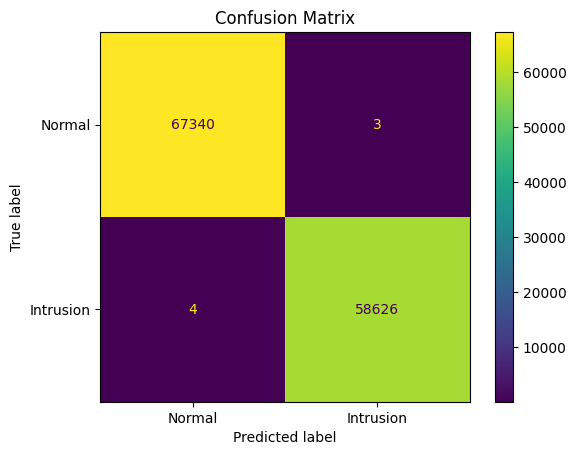

In [78]:
y_pred_train = model.predict(X_train_scaled)
cm = confusion_matrix(y_train, y_pred_train)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Intrusion"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

**Identify and visualize the most important network features that contribute to intrusion detection decisions made by the model.**

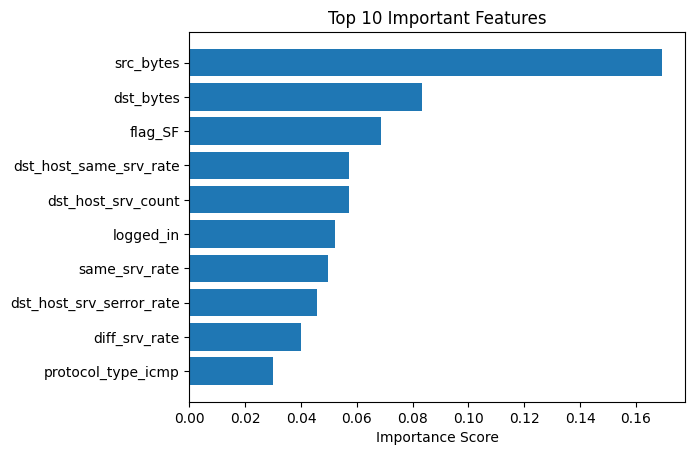

In [79]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

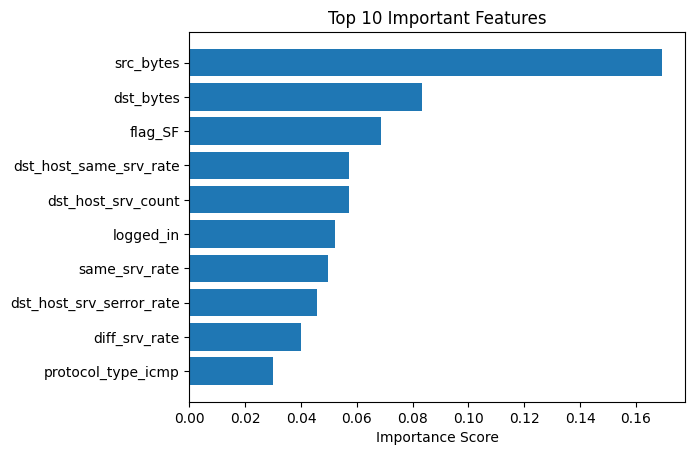

In [80]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

**Use the trained model to predict whether network traffic in the test dataset is normal or Intrusion.**

In [81]:
predictions = model.predict(X_test_scaled)

results = test_data.copy()
results['prediction'] = predictions
results['prediction'] = results['prediction'].map({
    0: 'Normal',
    1: 'Intrusion'
})

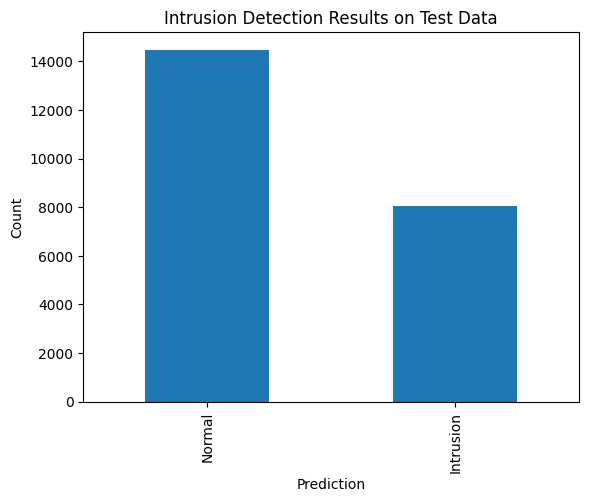

In [82]:
results['prediction'].value_counts().plot(kind='bar')
plt.title("Intrusion Detection Results on Test Data")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()